In [ ]:

# Data handling and Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from skl1earn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import class_weight

**Load Dataset and Show Info**

In [ ]:

col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"]


# Load full dataset (replace with your path)
df = pd.read_csv("KDDTrain+.csv",names=col_names)


# Show first rows
print("First rows of the dataset:")
print(df.head())


print("Number of samples (rows):", df.shape[0])
print("Number of features (columns):", df.shape[1])

First rows of the dataset:
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                    

In [ ]:
print(df.info())


print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

**Feature selection using Random Forest **

In [ ]:

# Separate features and target
X = df.drop('label', axis=1)
y = df['label']

# Encode categorical features
categorical_features = X.select_dtypes(include=['object']).columns
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Fit Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X, y)

# Get feature importances
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
})

# Sort and get top 20 features
top_20_features = feature_importances.sort_values(by='importance', ascending=False).head(20)

# Display results
top_20_features = top_20_features.reset_index(drop=True)
print(top_20_features)



                        feature  importance
0                     src_bytes    0.126683
1                 same_srv_rate    0.104158
2                 diff_srv_rate    0.082323
3                          flag    0.080100
4      dst_host_srv_serror_rate    0.051879
5                         count    0.041344
6                   serror_rate    0.040988
7                    difficulty    0.037701
8          dst_host_serror_rate    0.035903
9        dst_host_diff_srv_rate    0.035079
10                    dst_bytes    0.034932
11       dst_host_same_srv_rate    0.034152
12  dst_host_same_src_port_rate    0.033509
13              srv_serror_rate    0.033304
14                protocol_type    0.032817
15  dst_host_srv_diff_host_rate    0.029516
16           dst_host_srv_count    0.022331
17                    srv_count    0.020461
18                      service    0.020075
19               dst_host_count    0.018433


**Feature clasification:Numerical vs Categorical**

In [ ]:
# Select only top 20 features
top_features = top_20_features['feature'].tolist()
X_top = df[top_features]

# Separate numerical and categorical
numerical_features = X_top.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_top.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)




Numerical features: ['src_bytes', 'same_srv_rate', 'diff_srv_rate', 'dst_host_srv_serror_rate', 'count', 'serror_rate', 'difficulty', 'dst_host_serror_rate', 'dst_host_diff_srv_rate', 'dst_bytes', 'dst_host_same_srv_rate', 'dst_host_same_src_port_rate', 'srv_serror_rate', 'dst_host_srv_diff_host_rate', 'dst_host_srv_count', 'srv_count', 'dst_host_count']
Categorical features: ['flag', 'protocol_type', 'service']


**Exploratory Data Analysis (EDA)**

**Numerical Features Visualization**

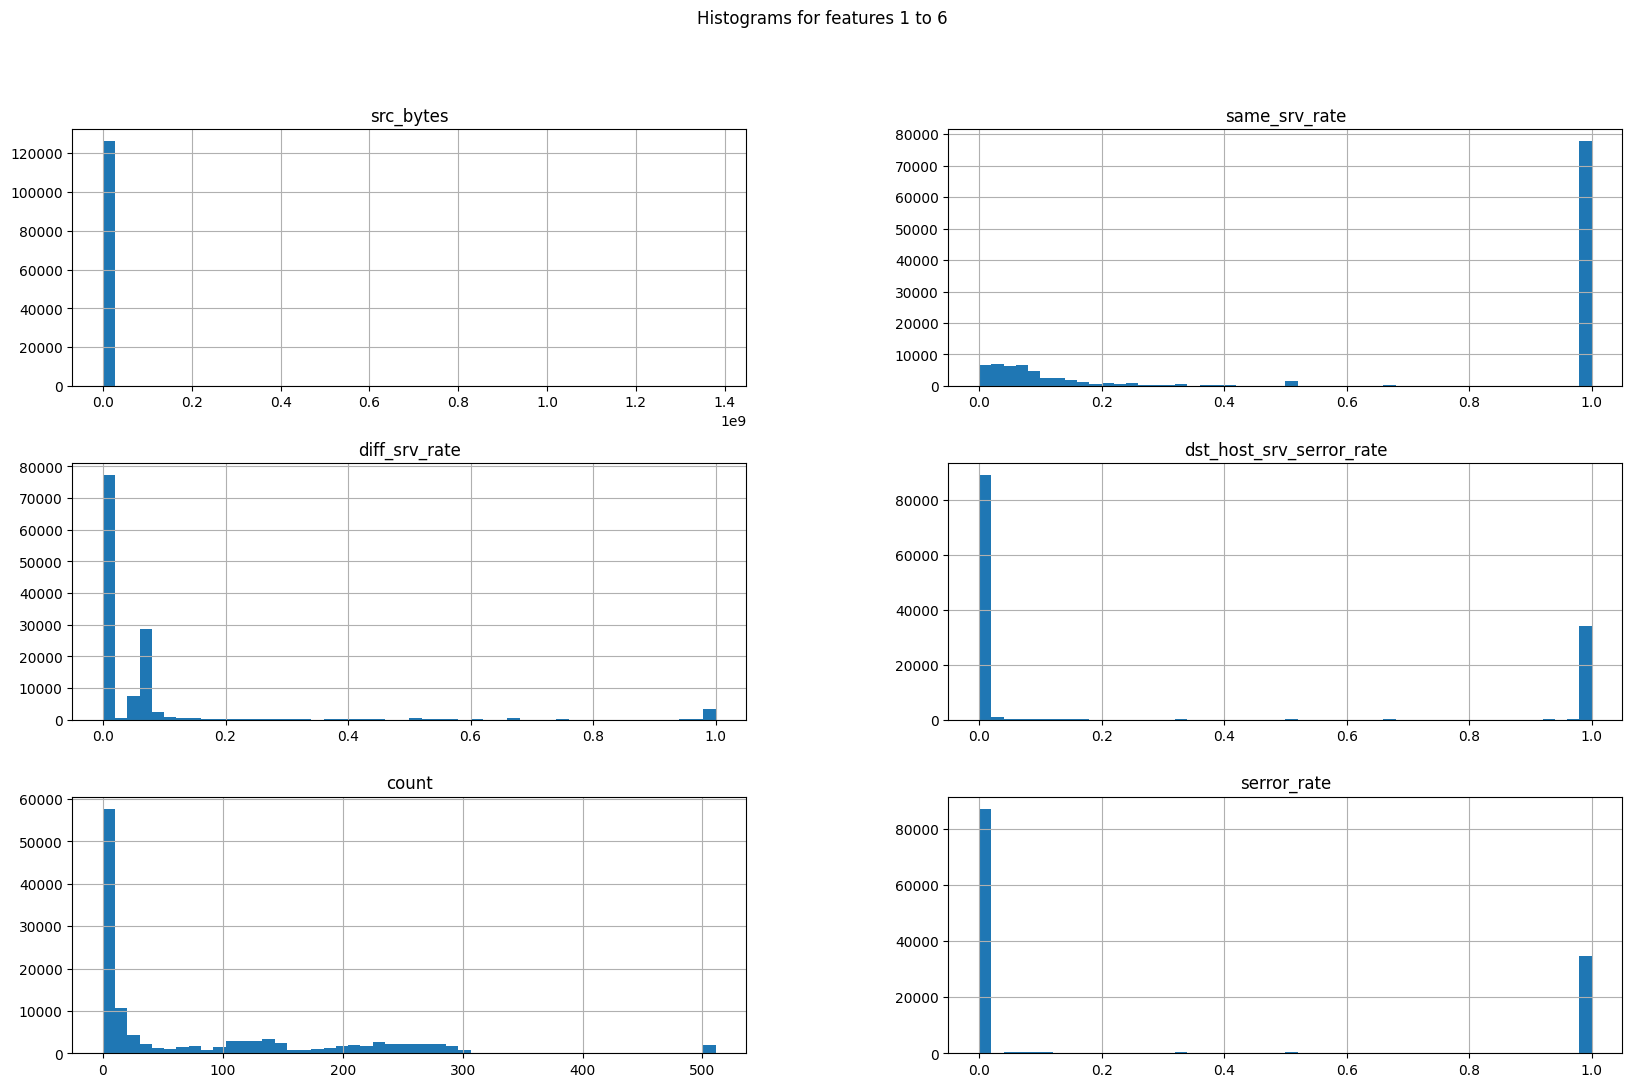

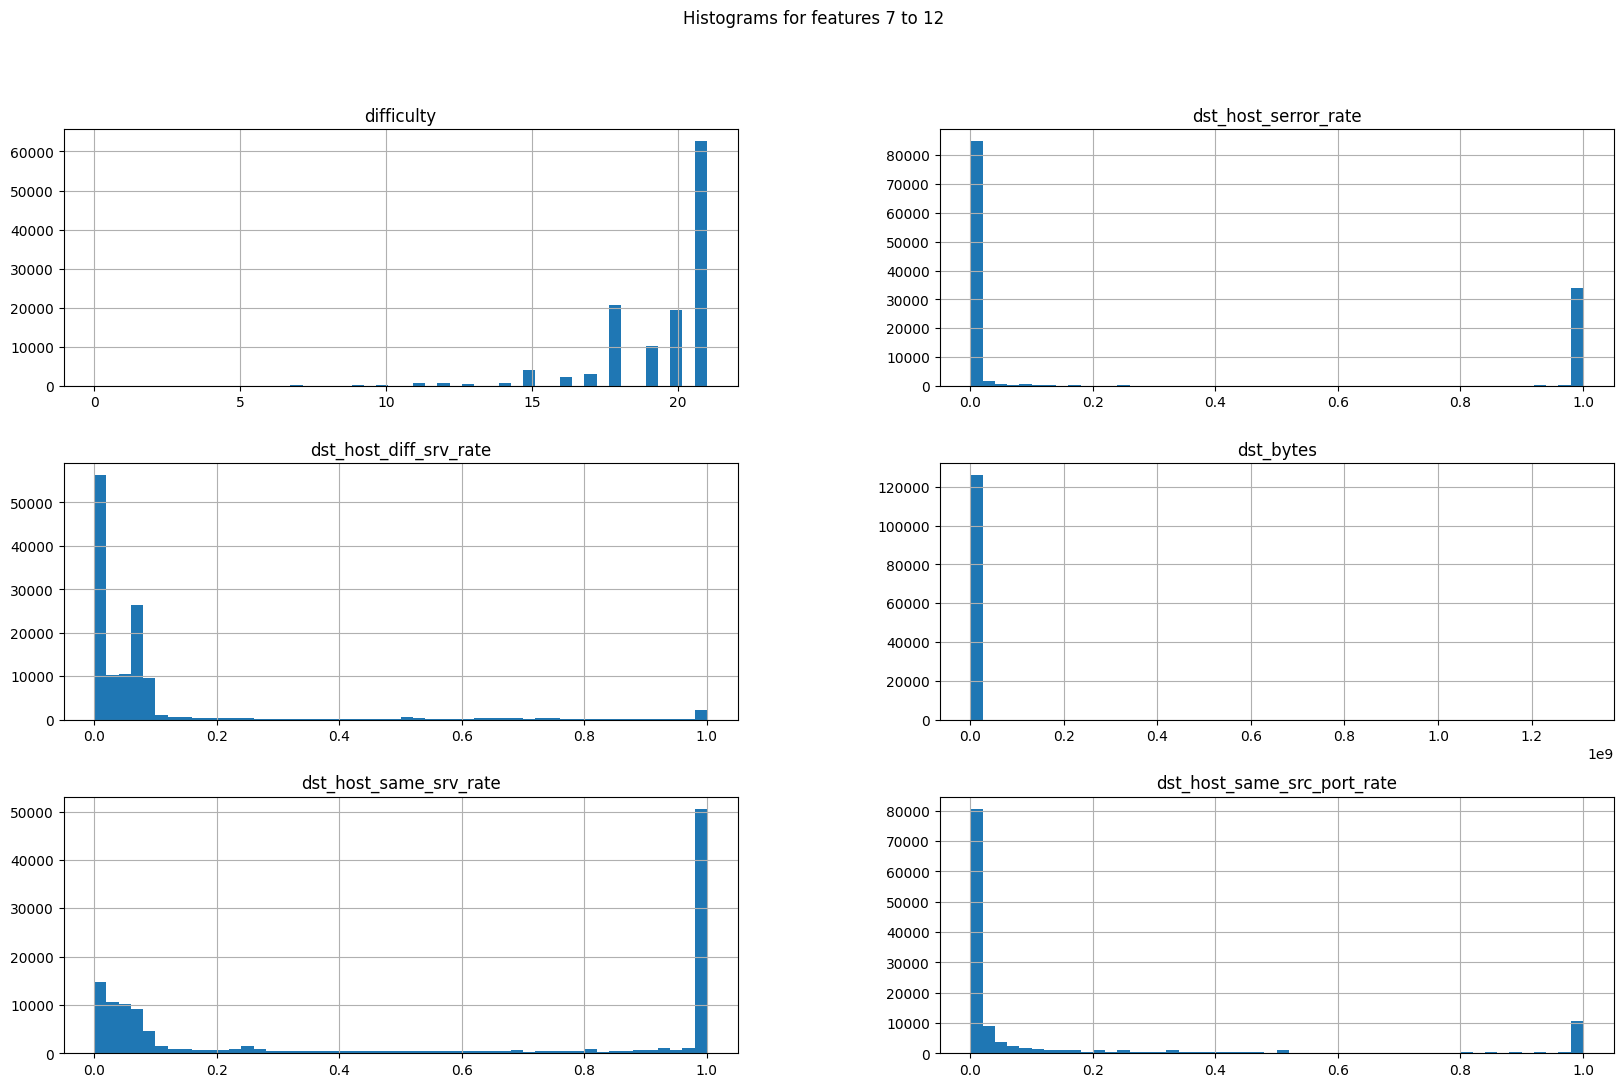

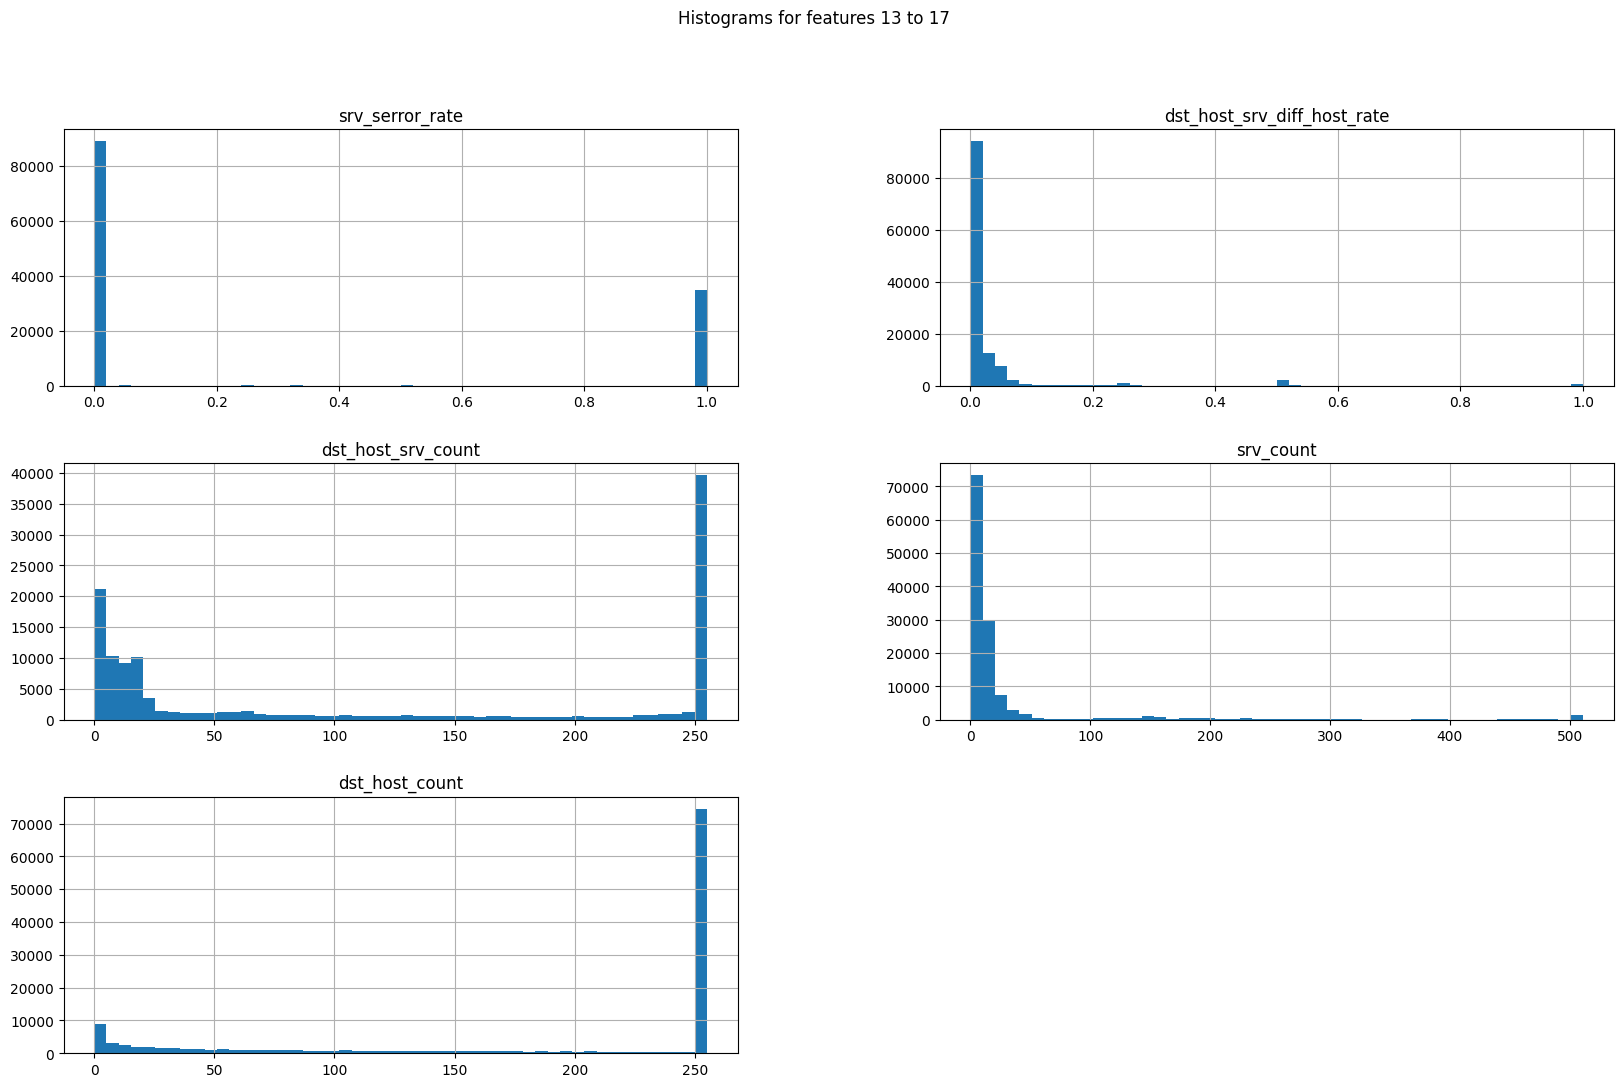

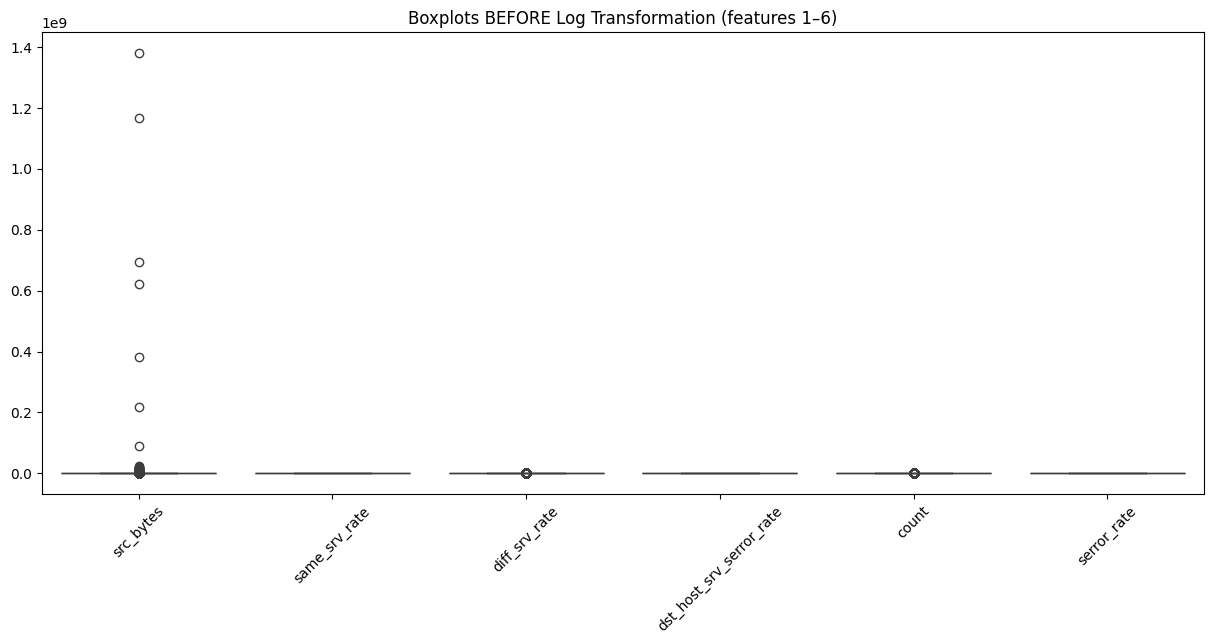

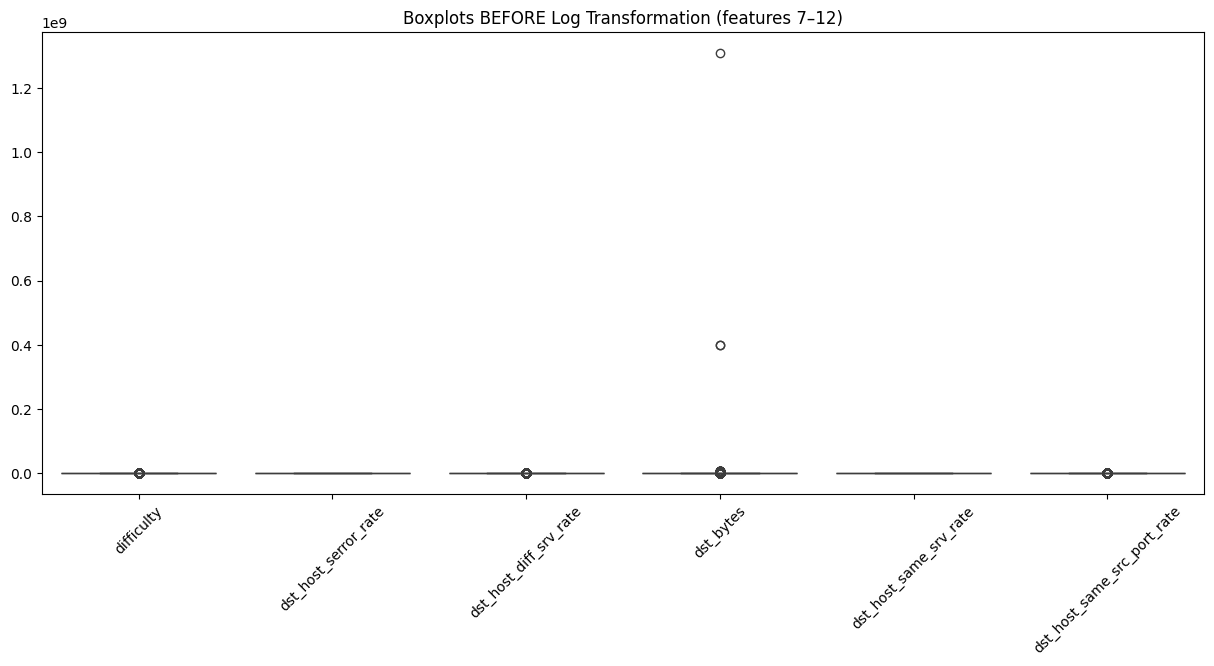

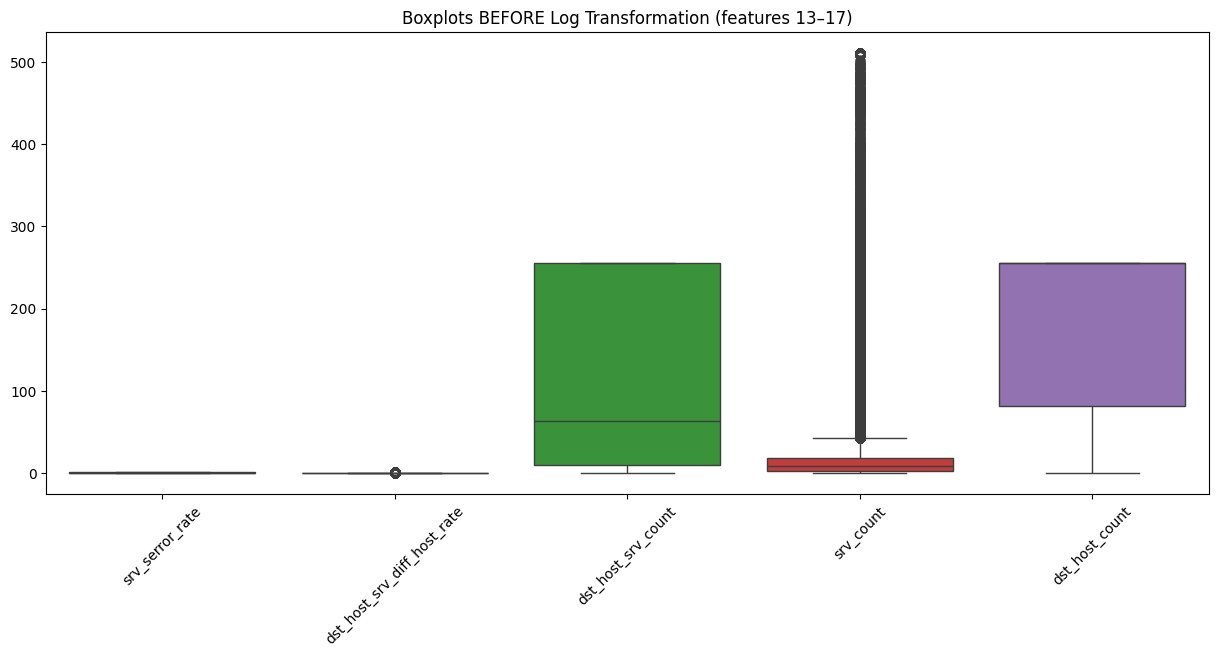

In [ ]:
# Select numerical features from top 20
numerical_features = X_top.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Histograms in batches
batch_size = 6
for i in range(0, len(numerical_features), batch_size):
    batch = numerical_features[i:i+batch_size]
    X_top[batch].hist(bins=50, figsize=(20, 12))
    plt.suptitle(f'Histograms for features {i+1} to {i+len(batch)}')
    plt.show()

# Boxplots for outliers
batch_size = 6
for i in range(0, len(numerical_features), batch_size):
    batch = numerical_features[i:i+batch_size]
    plt.figure(figsize=(15, 6))
    sns.boxplot(data=df[batch])
    plt.xticks(rotation=45)
    plt.title(f'Boxplots BEFORE Log Transformation (features {i+1}–{i+len(batch)})')
    plt.show()



**Log transformation for handling outliers**

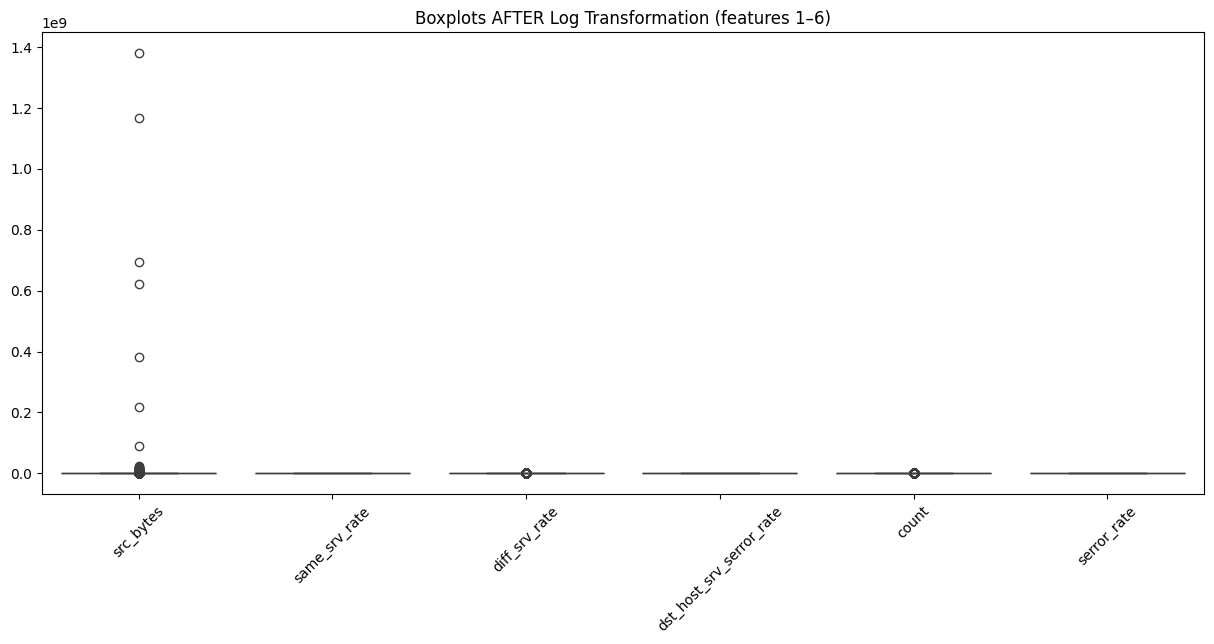

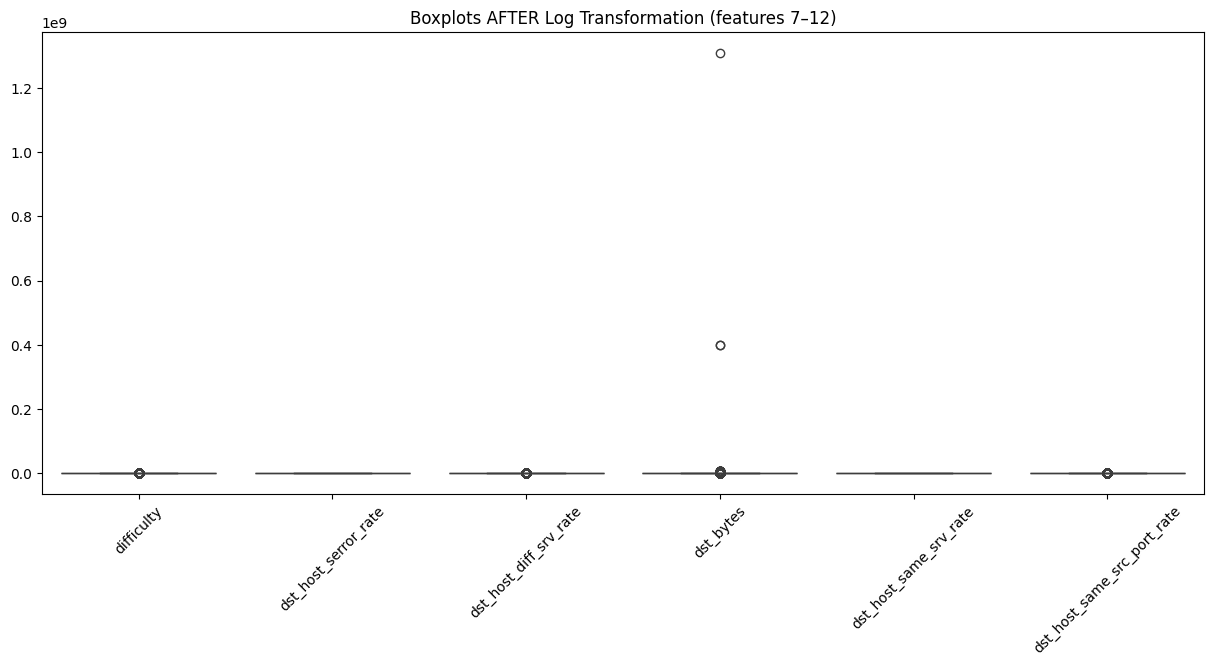

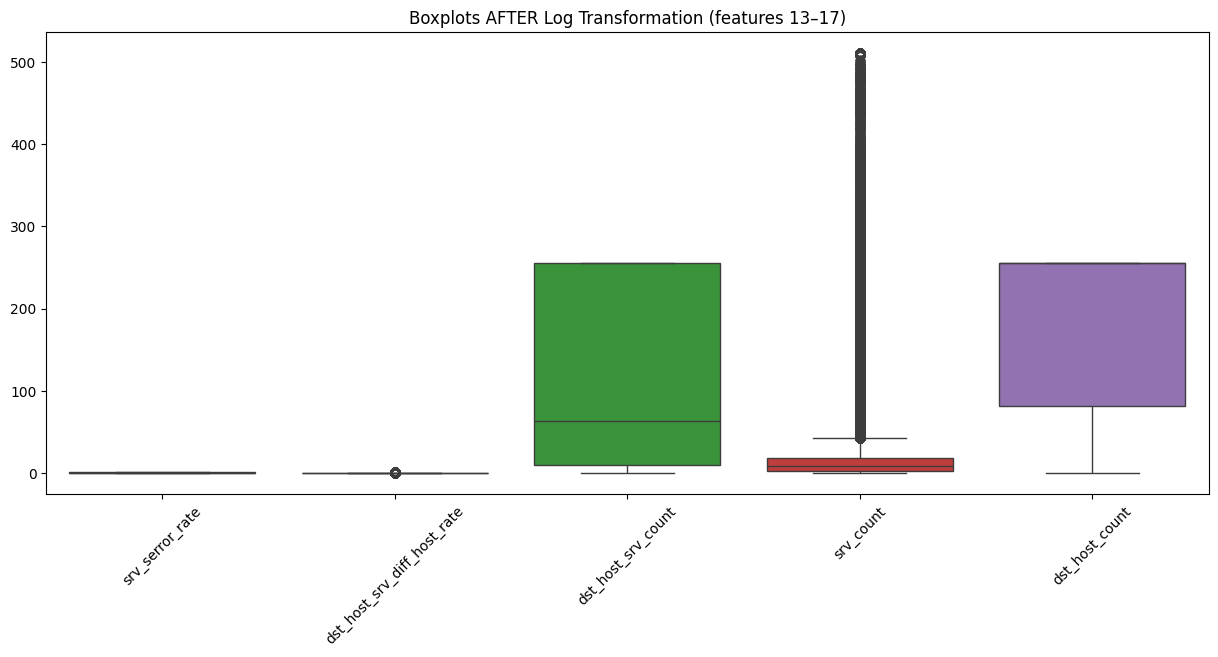

In [ ]:

# Select numerical features from top 20
numerical_features = X_top.select_dtypes(include=['int64', 'float64']).columns.tolist()

#  Apply log1p transformation (only for positive values)
df_log = df.copy()
for col in numerical_features:
    if (df_log[col] > 0).all():  # check all values positive
        df_log[col] = np.log1p(df_log[col])


# Boxplots for outliers after transformation
for i in range(0, len(numerical_features), batch_size):
    batch = numerical_features[i:i+batch_size]
    plt.figure(figsize=(15, 6))
    sns.boxplot(data=df_log[batch])
    plt.xticks(rotation=45)
    plt.title(f'Boxplots AFTER Log Transformation (features {i+1}–{i+len(batch)})')
    plt.show()




**Categorical Features Visualization**

/tmp/ipython-input-4272167903.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


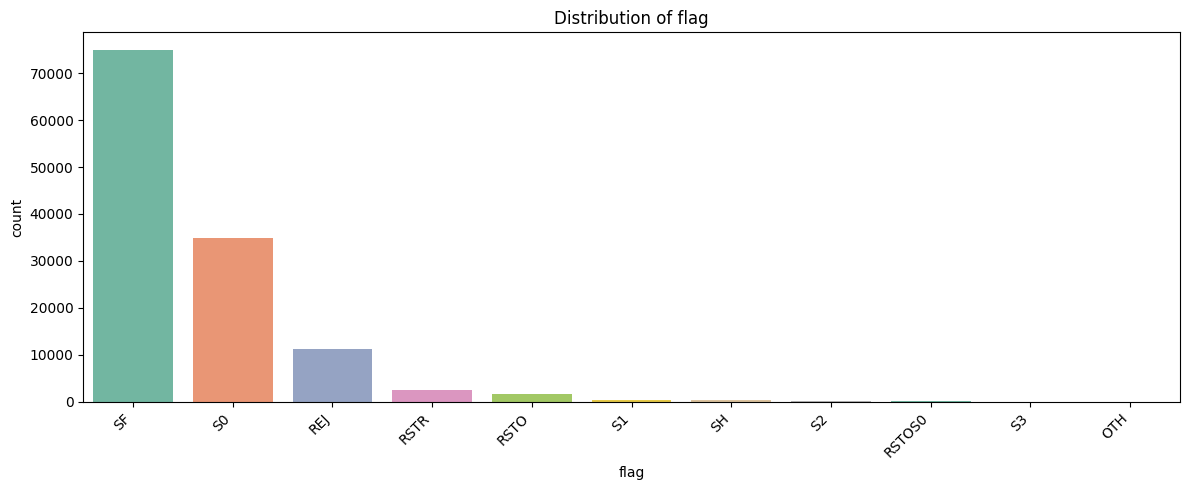

/tmp/ipython-input-4272167903.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


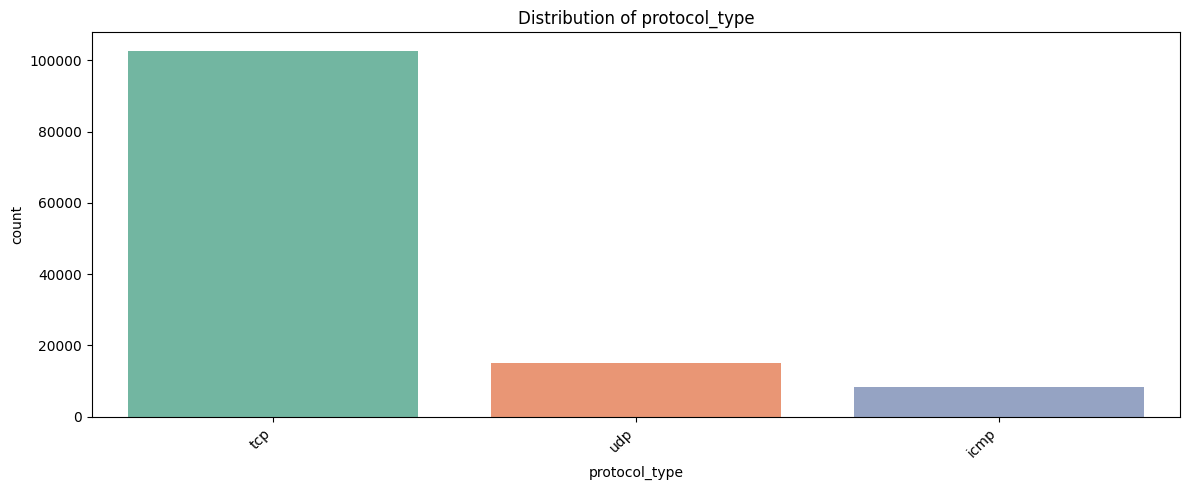

/tmp/ipython-input-4272167903.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


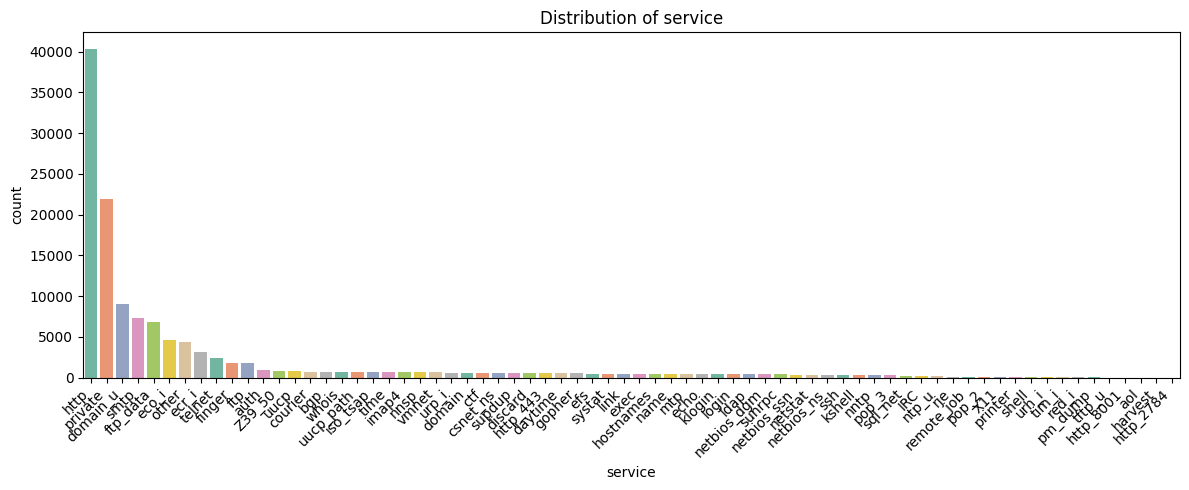

In [ ]:
for col in categorical_features:
    plt.figure(figsize=(12,5))
    sns.countplot(
        x=col,
        data=df,
        palette="Set2",
        order=df[col].value_counts().index
    )
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


**Binary target (attack vs normal)**

binary_attack
0    67343
1    58630
Name: count, dtype: int64


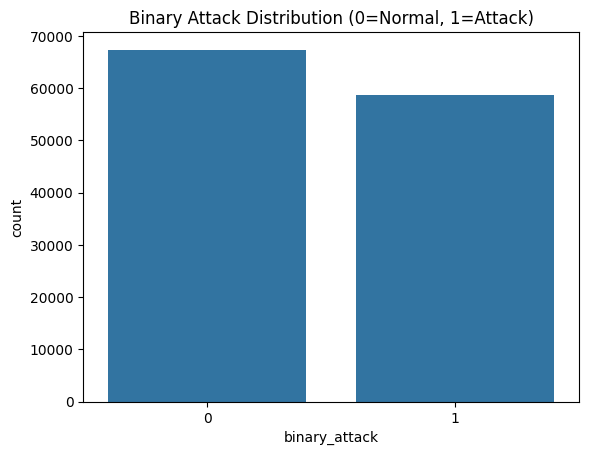

In [ ]:


df['binary_attack'] = df['label'].apply(lambda x: 0 if x=='normal' else 1)
print(df['binary_attack'].value_counts())
sns.countplot(x='binary_attack', data=df)
plt.title("Binary Attack Distribution (0=Normal, 1=Attack)")
plt.show()

**Target distribution and its visualization**

Raw Attack Type Distribution:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Normalized Distribution:
label
normal             0.534583
neptune            0.327165
satan              0.028840
ipsweep            0.028570
portsweep          0.023267
smurf              0.021005
nmap               0.011852
back               0.007589
teardrop           0.007081
warezclient        0.007065
pod                0.001596
guess_passwd       0.00

/tmp/ipython-input-627012704.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, order=df[target_col].value_counts().index, palette="Set2")


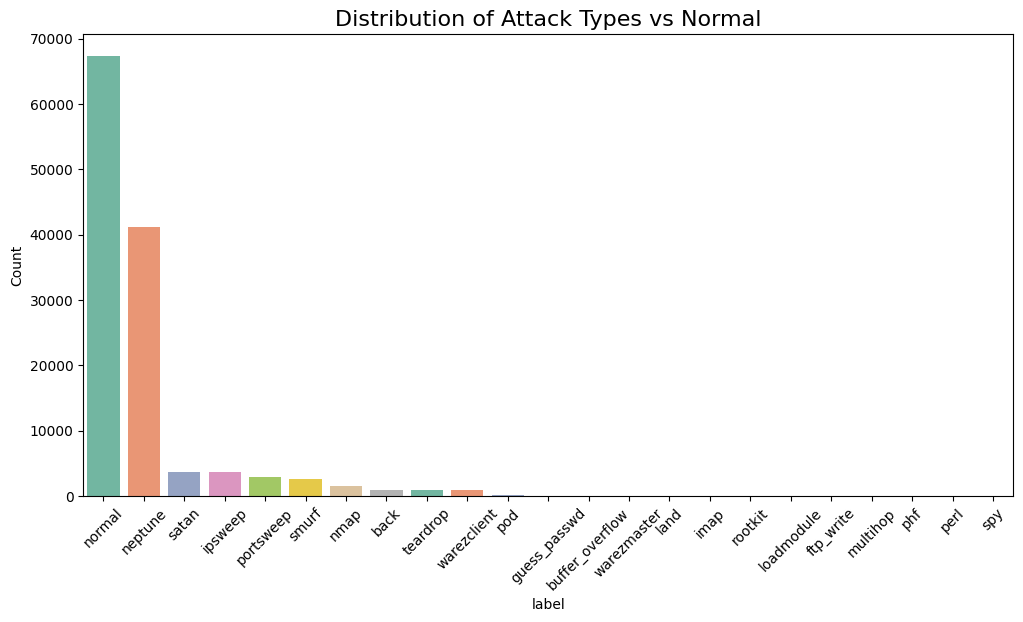

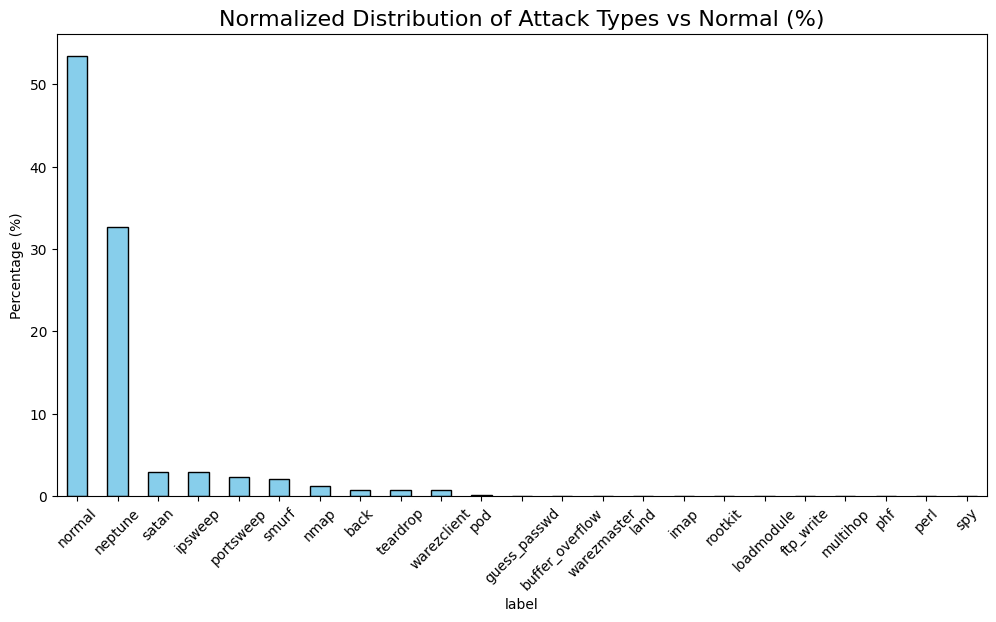

In [ ]:

# Assuming top_20_features is already defined
top_features = top_20_features['feature'].tolist()
X_top = df[top_features].copy()

# Define the target column
target_col = 'label'  # replace with your dataset's actual target column name

# Distribution of raw attack types
print("Raw Attack Type Distribution:")
print(df[target_col].value_counts())
print("\nNormalized Distribution:")
print(df[target_col].value_counts(normalize=True))

# Plot raw distribution (countplot)
plt.figure(figsize=(12,6))
sns.countplot(x=target_col, data=df, order=df[target_col].value_counts().index, palette="Set2")
plt.title("Distribution of Attack Types vs Normal", fontsize=16)
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

# Plot normalized distribution (percentage)
plt.figure(figsize=(12,6))
(df[target_col].value_counts(normalize=True) * 100).plot(kind='bar', color="skyblue", edgecolor="black")
plt.title("Normalized Distribution of Attack Types vs Normal (%)", fontsize=16)
plt.xticks(rotation=45)
plt.ylabel("Percentage (%)")
plt.show()

**Note:Data here is imbalanced , so we need to balance it before modeling**

**Group into 5 Classes (Multi-Class)**


Grouped Attack Class Distribution:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Normalized Distribution:
attack_class
normal    0.534583
DoS       0.364578
Probe     0.092528
R2L       0.007899
U2R       0.000413
Name: proportion, dtype: float64


/tmp/ipython-input-3060662647.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='attack_class', order=df['attack_class'].value_counts().index, palette="Set1")


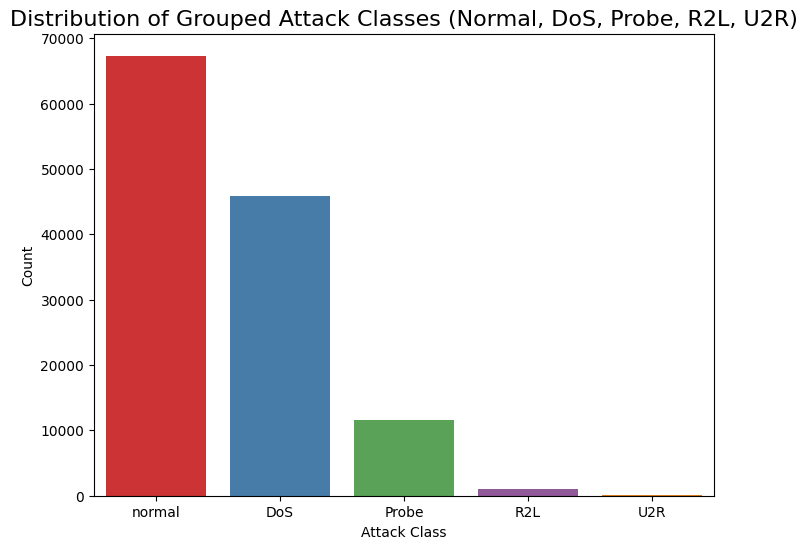

In [ ]:
attack_mapping = {
    'normal': 'normal',
    # DoS
    'neptune':'DoS','smurf':'DoS','back':'DoS','teardrop':'DoS','land':'DoS','pod':'DoS',
    # Probe
    'satan':'Probe','ipsweep':'Probe','nmap':'Probe','portsweep':'Probe',
    # R2L
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L',
    'phf':'R2L','spy':'R2L','warezclient':'R2L','warezmaster':'R2L',
    # U2R
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R'
}

df['attack_class'] = df['label'].map(attack_mapping)

# Grouped Attack Class Distribution
print("\nGrouped Attack Class Distribution:")
print(df['attack_class'].value_counts())
print("\nNormalized Distribution:")
print(df['attack_class'].value_counts(normalize=True))

# Plot Grouped Attack Classes
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='attack_class', order=df['attack_class'].value_counts().index, palette="Set1")
plt.title("Distribution of Grouped Attack Classes (Normal, DoS, Probe, R2L, U2R)", fontsize=16)
plt.xlabel("Attack Class")
plt.ylabel("Count")
plt.show()




** Data Preprocessing for Neural Network (MLP)**

In [ ]:

# Data Preprocessing for Neural Network (MLP)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical
from collections import Counter
import numpy as np

# Define mapping: attack types → 4 groups
dos_attacks = ['neptune', 'smurf', 'teardrop', 'back', 'pod', 'land']
probe_attacks = ['satan', 'ipsweep', 'nmap', 'portsweep']
r2l_u2r_attacks = ['guess_passwd', 'ftp_write', 'imap', 'phf', 'multihop',
                   'warezmaster', 'warezclient', 'spy', 'xlock', 'xsnoop',
                   'snmpguess', 'snmpgetattack', 'named', 'sendmail',
                   'buffer_overflow', 'loadmodule', 'rootkit', 'perl']

def map_attack(label):
    if label == 'normal':
        return 'normal'
    elif label in dos_attacks:
        return 'DoS'
    elif label in probe_attacks:
        return 'probe'
    else:
        return 'other'

# Apply grouping
df_mod = df.copy()
df_mod['label'] = df_mod['label'].apply(map_attack)

# Identify categorical columns
categorical_cols = df_mod.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('label')
print("Categorical columns to encode:", categorical_cols)

# One-hot encode categorical features
df_encoded = pd.get_dummies(df_mod, columns=categorical_cols)

# Separate features and target
X = df_encoded.drop('label', axis=1).values
y_labels = df_encoded['label'].values

# Encode target labels (integer encoding) and one-hot for MLP
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
y = to_categorical(y_encoded)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert one-hot back to integer labels
y_train_int = np.argmax(y_train, axis=1)

# Balancing classes
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weights_dict = dict(enumerate(class_weights))

print("Class weights for training:", class_weights_dict)
print("Data preprocessing completed!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Classes:", label_encoder.classes_)


Categorical columns to encode: ['protocol_type', 'service', 'flag', 'attack_class']
Class weights for training: {0: np.float64(0.6857325603549168), 1: np.float64(0.4676560121765601), 2: np.float64(30.065035799522672), 3: np.float64(2.701823056300268)}
Data preprocessing completed!
X_train shape: (100778, 129)
X_test shape: (25195, 129)
y_train shape: (100778, 4)
y_test shape: (25195, 4)
Classes: ['DoS' 'normal' 'other' 'probe']


**Neural Network(MLP) Model**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9520 - loss: 0.1964 - val_accuracy: 0.9996 - val_loss: 0.0048
Epoch 2/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9984 - loss: 0.0152 - val_accuracy: 1.0000 - val_loss: 4.2715e-04
Epoch 3/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 0.9998 - val_loss: 0.0012
Epoch 4/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9998 - loss: 0.0014 - val_accuracy: 0.9997 - val_loss: 0.0014
Epoch 5/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9995 - loss: 0.0042 - val_accuracy: 0.9999 - val_loss: 0.0017
Epoch 6/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9996 - loss: 0.0169 - val_accuracy: 0.9998 - val_loss: 0.0019
Epoch 7/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9994 - loss: 0.0049 - val_accuracy: 0.9999 - val_loss: 0.0060
Epoch 8/30
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9998 - loss: 0.00

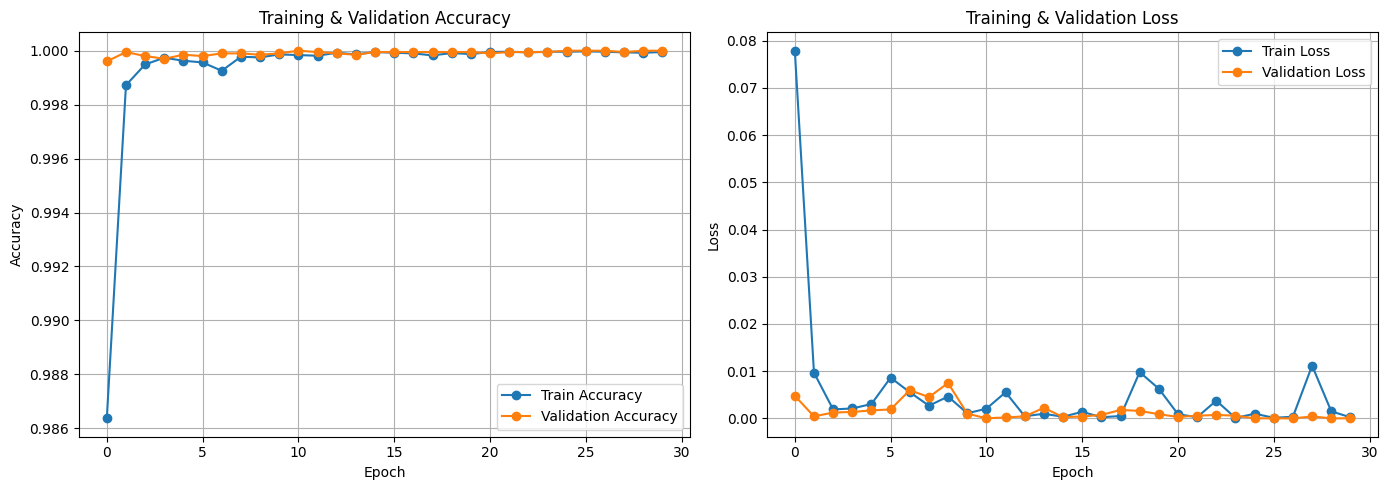

788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      normal       1.00      1.00      1.00     13469
       other       1.00      1.00      1.00       209
       probe       1.00      1.00      1.00      2331

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



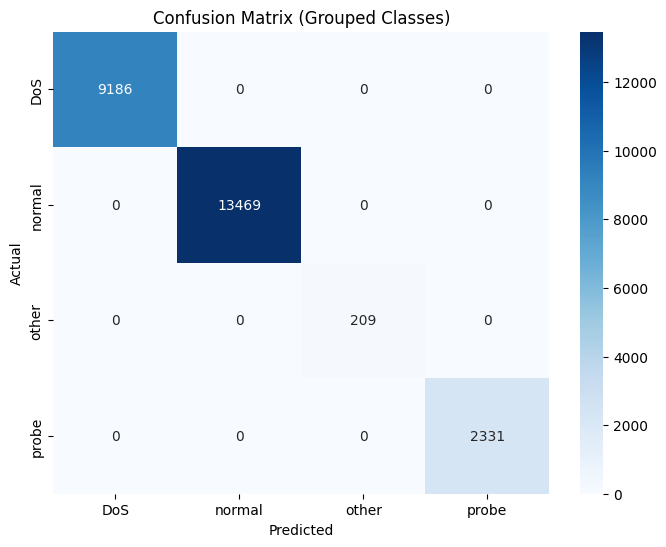

In [ ]:
# Neural Network (MLP) Training and Evaluation with Class Weights

import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Define MLP model
input_dim = X_train.shape[1]  # number of features after one-hot encoding
num_classes = y_train.shape[1]  # number of output classes (normal + grouped attacks)

model = Sequential()
model.add(Dense(128, input_dim=input_dim, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model with validation and class weights
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights_dict,  # balancing rare vs frequent
    verbose=1
)

# Visualize Training Accuracy & Loss
plt.figure(figsize=(14,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.grid(True)
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on Test Data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Use the same class order as LabelEncoder
grouped_classes = label_encoder.classes_

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=grouped_classes))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=grouped_classes,
            yticklabels=grouped_classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Grouped Classes)')
plt.show()


# Random Forest

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

columns = [
 'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
 'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
 'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds',
 'is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
 'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
 'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
 'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
 'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label'
]
df = pd.read_csv("KDDTrain+.csv", names=columns)

num_cols = df.columns.difference(['protocol_type','service','flag','label'])
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

df = pd.get_dummies(df, columns=['protocol_type','service','flag'])

X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


FileNotFoundError: [Errno 2] No such file or directory: 'KDDTrain+.csv'

**Decision Tree**


[CV] Using n_splits = 2 (min_class_count = 2)
Fitting 2 folds for each of 108 candidates, totalling 216 fits
[DT] Best Params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

[Decision Tree (tuned)] Accuracy: 0.9984

                 precision    recall  f1-score   support

           back       1.00      1.00      1.00       191
buffer_overflow       0.80      0.67      0.73         6
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       1.00      0.91      0.95        11
           imap       1.00      1.00      1.00         2
        ipsweep       1.00      0.99      1.00       720
           land       1.00      1.00      1.00         4
     loadmodule       0.33      0.50      0.40         2
       multihop       0.50      1.00      0.67         1
        neptune       1.00      1.00      1.00      8243
           nmap       0.98      1.00      0.99       299
         normal       1.00      1.00      1.00     13469


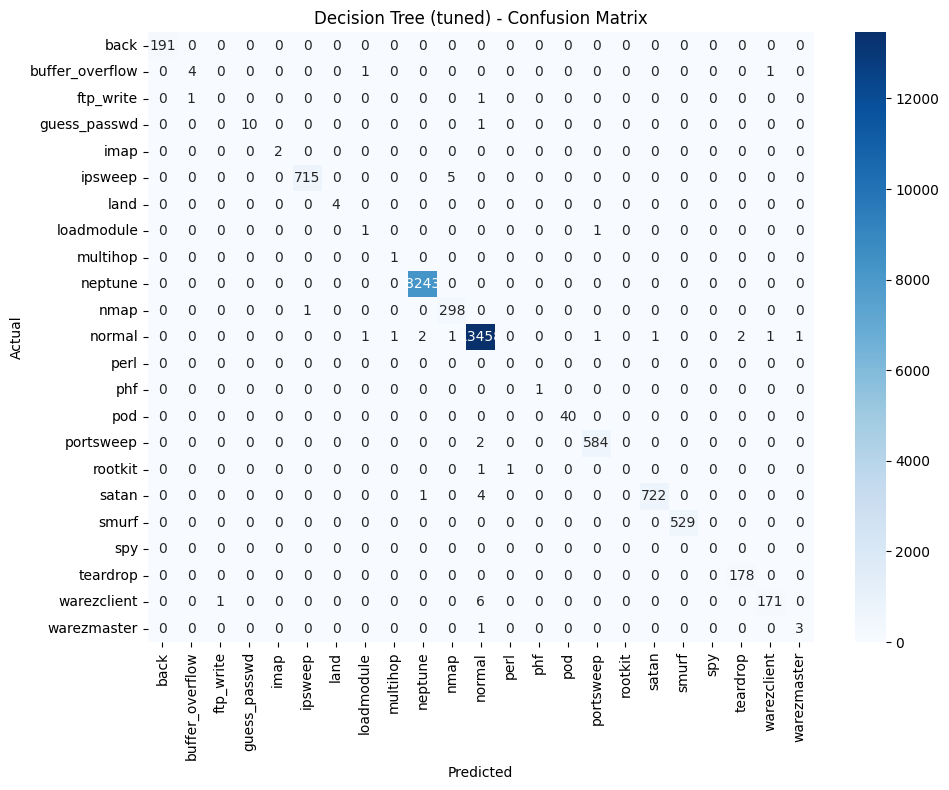

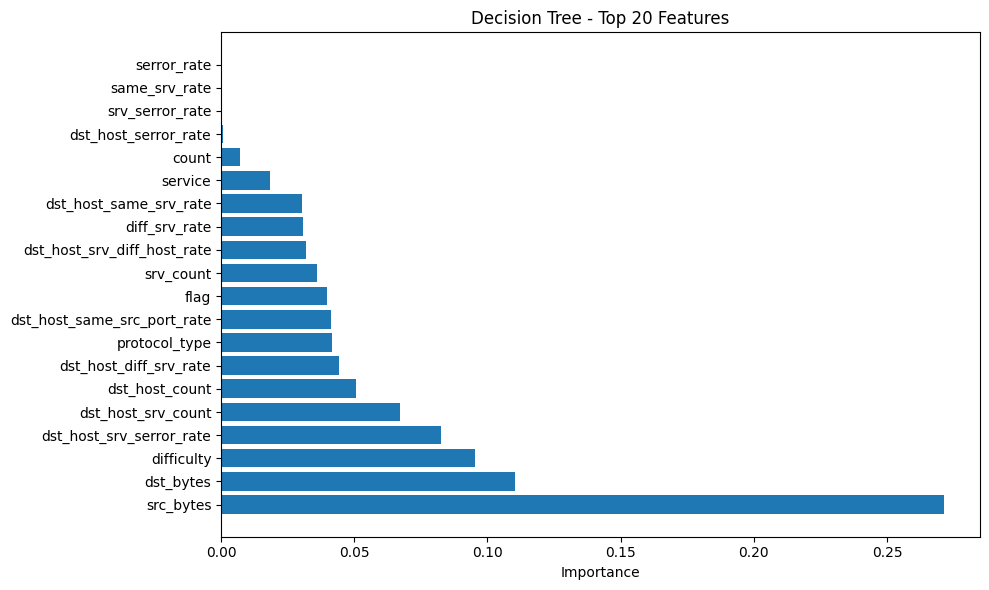

In [ ]:
# ===== Decision Tree (tuned) =====
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier

# ----- Features (from your previous step) -----
top_features = top_20_features['feature'].tolist()
X_top = df[top_features].copy()

# Encode any categorical columns defensively
for c in X_top.columns:
    if X_top[c].dtype == 'object':
        X_top[c] = LabelEncoder().fit_transform(X_top[c].astype(str))

# Target: use full multiclass labels (not binary)
y_raw = df['label'].astype(str).copy()
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_

# ----- Split -----
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.20, stratify=y, random_state=42
)

# Auto CV folds based on rarest class
min_class_count = pd.Series(y_train).value_counts().min()
n_splits_auto = max(2, min(5, int(min_class_count)))
cv = StratifiedKFold(n_splits=n_splits_auto, shuffle=True, random_state=42)
print(f"[CV] Using n_splits = {n_splits_auto} (min_class_count = {min_class_count})")

# ----- Helpers -----
def evaluate_model(name, model, X_test, y_test, class_names):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n[{name}] Accuracy: {acc:.4f}\n")

    # Force full label set to keep lengths consistent even if a class is missing
    all_labels = list(range(len(class_names)))
    print(classification_report(
        y_test, y_pred, labels=all_labels, target_names=class_names, zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred, labels=all_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} - Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

def plot_top_importances(model, feature_names, top_k=20, title="Top Features"):
    if not hasattr(model, "feature_importances_"):
        print("[Warn] No feature_importances_."); return
    importances = model.feature_importances_
    order = np.argsort(importances)[::-1][:top_k]
    feats = np.array(feature_names)[order]; vals = importances[order]
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(feats))[::-1], vals[::-1])
    plt.yticks(range(len(feats))[::-1], feats[::-1])
    plt.title(title); plt.xlabel("Importance")
    plt.tight_layout(); plt.show()

# ----- Model + GridSearch -----
dt = DecisionTreeClassifier(class_weight="balanced", random_state=42)
param_dt = {
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy", "log_loss"],
}
grid_dt = GridSearchCV(dt, param_dt, cv=cv, n_jobs=-1, verbose=1)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
print("[DT] Best Params:", grid_dt.best_params_)
evaluate_model("Decision Tree (tuned)", best_dt, X_test, y_test, class_names)
plot_top_importances(best_dt, X_top.columns, 20, title="Decision Tree - Top 20 Features")


**XGBoost**

[CV] Using n_splits = 2 (min_class_count = 2)
Fitting 2 folds for each of 48 candidates, totalling 96 fits
[XGBoost] Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400, 'subsample': 1.0}

[XGBoost (tuned)] Accuracy: 0.9991

                 precision    recall  f1-score   support

           back       0.99      1.00      1.00       191
buffer_overflow       1.00      0.83      0.91         6
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       1.00      0.91      0.95        11
           imap       1.00      1.00      1.00         2
        ipsweep       1.00      0.99      0.99       720
           land       1.00      1.00      1.00         4
     loadmodule       1.00      0.50      0.67         2
       multihop       0.00      0.00      0.00         1
        neptune       1.00      1.00      1.00      8243
           nmap       0.98      1.00      0.99       299
         normal       1.00      1.00      1.0

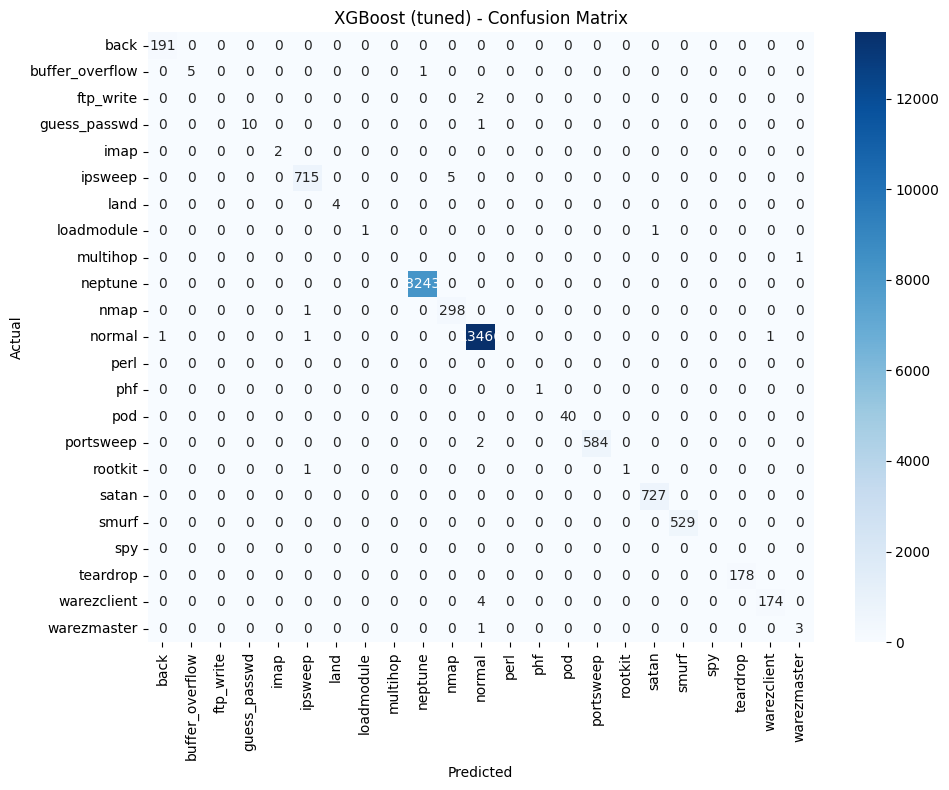

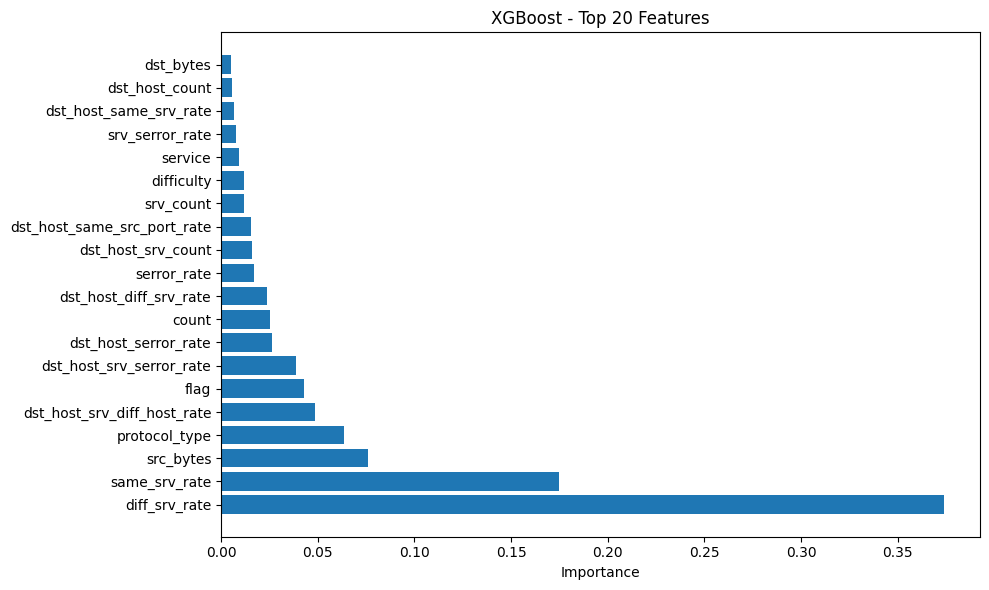

In [ ]:
# ===== XGBoost (tuned) =====
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

# ----- Features -----
top_features = top_20_features['feature'].tolist()
X_top = df[top_features].copy()

for c in X_top.columns:
    if X_top[c].dtype == 'object':
        X_top[c] = LabelEncoder().fit_transform(X_top[c].astype(str))

# Target
y_raw = df['label'].astype(str).copy()
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_
n_classes = len(class_names)


# CV
min_class_count = pd.Series(y_train).value_counts().min()
n_splits_auto = max(2, min(5, int(min_class_count)))
cv = StratifiedKFold(n_splits=n_splits_auto, shuffle=True, random_state=42)
print(f"[CV] Using n_splits = {n_splits_auto} (min_class_count = {min_class_count})")



# Model + Grid
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    random_state=42,
    nthread=-1
)
param_xgb = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}
grid_xgb = GridSearchCV(xgb, param_xgb, cv=cv, n_jobs=-1, verbose=1)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
print("[XGBoost] Best Params:", grid_xgb.best_params_)
evaluate_model("XGBoost (tuned)", best_xgb, X_test, y_test, class_names)
plot_top_importances(best_xgb, X_top.columns, 20, title="XGBoost - Top 20 Features")


**KNN**

In [ ]:
print(df.shape)
n = df.shape[0]
print("Number of samples (n):", n)
sqrt_n = np.sqrt(n)
print("√n =", sqrt_n)

(125973, 44)
Number of samples (n): 125973
√n = 354.9267530068704


In [ ]:
# ===== KNN (tuned, scaled) =====
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# ----- Features -----
top_features = top_20_features['feature'].tolist()
X_top = df[top_features].copy()

for c in X_top.columns:
    if X_top[c].dtype == 'object':
        X_top[c] = LabelEncoder().fit_transform(X_top[c].astype(str))

# Target
y_raw = df['label'].astype(str).copy()
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_



# CV
min_class_count = pd.Series(y_train).value_counts().min()
n_splits_auto = max(2, min(5, int(min_class_count)))
cv = StratifiedKFold(n_splits=n_splits_auto, shuffle=True, random_state=42)
print(f"[CV] Using n_splits = {n_splits_auto} (min_class_count = {min_class_count})")


# Pipeline + Grid
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])
param_knn = {
    "knn__n_neighbors": [5, 11, 21, 31],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}
grid_knn = GridSearchCV(pipe_knn, param_knn, cv=cv, n_jobs=-1, verbose=1)
grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_
print("[KNN] Best Params:", grid_knn.best_params_)
evaluate_model("KNN (tuned, scaled)", best_knn, X_test, y_test, class_names)



Naive bayes


In [ ]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import GaussianNB

# Features
top_features = top_20_features['feature'].tolist()
X_top = df[top_features].copy()
for c in X_top.columns:
    if X_top[c].dtype == 'object':
        X_top[c] = LabelEncoder().fit_transform(X_top[c].astype(str))

# Target
y_raw = df['label'].astype(str)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_
all_labels = list(range(len(class_names)))



# Train & Eval
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n[GaussianNB] Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, labels=all_labels,
                            target_names=class_names, zero_division=0))
cm = confusion_matrix(y_test, y_pred, labels=all_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("GaussianNB - Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, Binarizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import BernoulliNB

top_features = top_20_features['feature'].tolist()
X_top = df[top_features].copy()
for c in X_top.columns:
    if X_top[c].dtype == 'object':
        X_top[c] = LabelEncoder().fit_transform(X_top[c].astype(str))

bin_thresh = X_top.median(axis=0).values
X_bin = (X_top.values >= bin_thresh).astype(int)
X_bin = pd.DataFrame(X_bin, columns=X_top.columns, index=X_top.index)

y_raw = df['label'].astype(str)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_
all_labels = list(range(len(class_names)))

X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y, test_size=0.20, stratify=y, random_state=42
)

bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred = bnb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n[BernoulliNB] Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, labels=all_labels,
                            target_names=class_names, zero_division=0))
cm = confusion_matrix(y_test, y_pred, labels=all_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("BernoulliNB (Binarized) - Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import MultinomialNB

top_features = top_20_features['feature'].tolist()
X_top = df[top_features].copy()
for c in X_top.columns:
    if X_top[c].dtype == 'object':
        X_top[c] = LabelEncoder().fit_transform(X_top[c].astype(str))

scaler = MinMaxScaler()
X_mn = scaler.fit_transform(X_top) + 1e-6  # avoid exact zeros

y_raw = df['label'].astype(str)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_
all_labels = list(range(len(class_names)))

X_train, X_test, y_train, y_test = train_test_split(
    X_mn, y, test_size=0.20, stratify=y, random_state=42
)

mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n[MultinomialNB] Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, labels=all_labels,
                            target_names=class_names, zero_division=0))
cm = confusion_matrix(y_test, y_pred, labels=all_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("MultinomialNB (MinMax) - Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()


In [ ]:

from sklearn.naive_bayes import ComplementNB

top_features = top_20_features['feature'].tolist()
X_top = df[top_features].copy()
for c in X_top.columns:
    if X_top[c].dtype == 'object':
        X_top[c] = LabelEncoder().fit_transform(X_top[c].astype(str))

scaler = MinMaxScaler()
X_cp = scaler.fit_transform(X_top) + 1e-6

y_raw = df['label'].astype(str)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_
all_labels = list(range(len(class_names)))

X_train, X_test, y_train, y_test = train_test_split(
    X_cp, y, test_size=0.20, stratify=y, random_state=42
)

cnb = ComplementNB(alpha=1.0)
cnb.fit(X_train, y_train)
y_pred = cnb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n[ComplementNB] Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, labels=all_labels,
                            target_names=class_names, zero_division=0))
cm = confusion_matrix(y_test, y_pred, labels=all_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("ComplementNB (MinMax) - Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()


In [ ]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import CategoricalNB

top_features = top_20_features['feature'].tolist()
X_top = df[top_features].copy()

# split columns by dtype
num_cols = [c for c in X_top.columns if np.issubdtype(X_top[c].dtype, np.number)]
cat_cols = [c for c in X_top.columns if X_top[c].dtype == 'object']

# encode categorical to integers 0..K-1
for c in cat_cols:
    X_top[c] = LabelEncoder().fit_transform(X_top[c].astype(str))

# discretize numeric to categories
if len(num_cols) > 0:
    kb = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
    X_top[num_cols] = kb.fit_transform(X_top[num_cols]).astype(int)

# ensure all columns are integer categories
X_cat = X_top.astype(int)

y_raw = df['label'].astype(str)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_
all_labels = list(range(len(class_names)))

X_train, X_test, y_train, y_test = train_test_split(
    X_cat, y, test_size=0.20, stratify=y, random_state=42
)

cnb = CategoricalNB()
cnb.fit(X_train, y_train)
y_pred = cnb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n[CategoricalNB] Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, labels=all_labels,
                            target_names=class_names, zero_division=0))
cm = confusion_matrix(y_test, y_pred, labels=all_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("CategoricalNB (Discretized) - Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()
